Doing a Customer Churn Prediction Project 

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df= pd.read_csv("Customer_Churn.csv")
print (df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

CSV is loaded successfully now I have to understand the data and clean it if needed.

In [20]:
print(df.info())
print(df.columns)
print(df.isna)
print(df.notnull)
print(df.isnull)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
to_numeric=df['TotalCharges']
to_numeric=pd.to_numeric(to_numeric, errors='coerce')
print(to_numeric)
print(df.info())

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechS

In [22]:
print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [23]:
print("isnull total", df.isnull().sum().sum())

isnull total 0


In [24]:
check= pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows that failed to convert:", check.isna().sum())
print("Thier tenure values:", df.loc[check.isna(), "tenure"].unique())

Rows that failed to convert: 11
Thier tenure values: [0]


In [25]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"]=df["TotalCharges"].fillna(0)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df["Churn"]=df["Churn"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerID"])  # just an ID, not useful for the model

print("Churn rate:", df["Churn"].mean())

Churn rate: 0.2653698707936959


Contract
Two year          0.028319
One year          0.112695
Month-to-month    0.427097
Name: Churn, dtype: float64


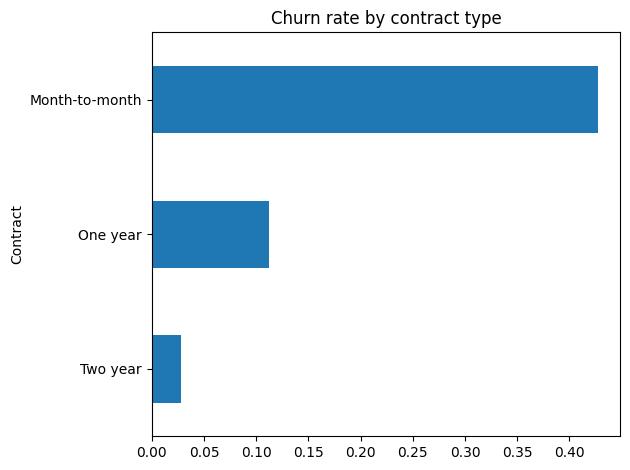

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

contract_churn = df.groupby("Contract")["Churn"].mean().sort_values()
print(contract_churn)
contract_churn.plot(kind="barh", title="Churn rate by contract type")
plt.tight_layout()
plt.show()


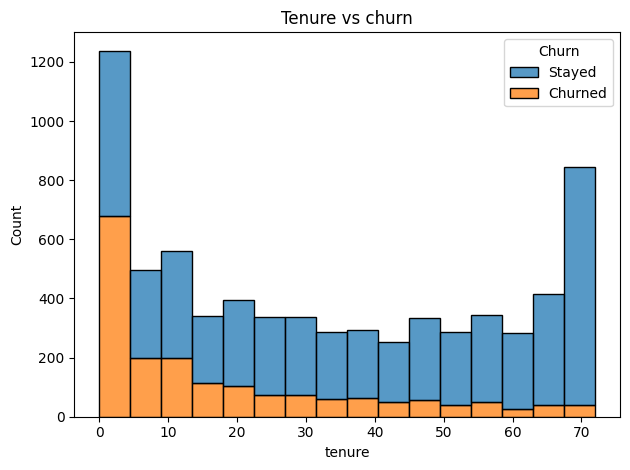

In [28]:
sns.histplot(data=df, x="tenure", hue=df["Churn"].map({1: "Churned", 0: "Stayed"}), multiple="stack")
plt.title("Tenure vs churn")
plt.tight_layout()
plt.show()


In [29]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

y = df["Churn"]
X = df.drop(columns=["Churn"])

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 3), "| Test churn rate:", round(y_test.mean(), 3))

Train: (5634, 19) Test: (1409, 19)
Train churn rate: 0.265 | Test churn rate: 0.265


In [15]:

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    print(name, {m: round(np.mean(scores[f"test_{m}"]), 3) for m in scoring})

Logistic Regression {'accuracy': 0.749, 'precision': 0.517, 'recall': 0.801, 'f1': 0.628, 'roc_auc': 0.846}
Random Forest {'accuracy': 0.78, 'precision': 0.569, 'recall': 0.705, 'f1': 0.629, 'roc_auc': 0.843}
XGBoost {'accuracy': 0.76, 'precision': 0.533, 'recall': 0.773, 'f1': 0.631, 'roc_auc': 0.844}


              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.842


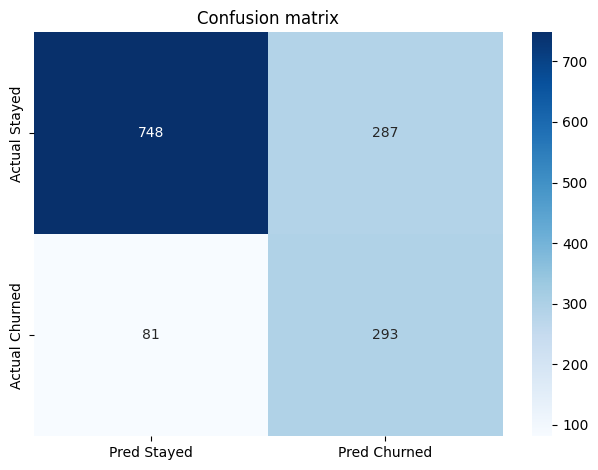

In [30]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

best_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])
best_pipe.fit(X_train, y_train)

pred = best_pipe.predict(X_test)
proba = best_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, target_names=["Stayed", "Churned"]))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Stayed", "Pred Churned"], yticklabels=["Actual Stayed", "Actual Churned"])
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()


In [31]:

feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(best_pipe.named_steps["clf"].coef_[0], index=feature_names)

print("Increases churn odds:")
print(coefs.sort_values(ascending=False).head(6).round(3))
print("\nDecreases churn odds:")
print(coefs.sort_values().head(6).round(3))
print("\nCorrelation check (are these 3 too similar to each other?):")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(3))

Increases churn odds:
cat__InternetService_Fiber optic    0.656
cat__Contract_Month-to-month        0.625
num__TotalCharges                   0.492
cat__PaperlessBilling_Yes           0.334
cat__StreamingMovies_Yes            0.233
cat__StreamingTV_Yes                0.220
dtype: float64

Decreases churn odds:
num__tenure                                -1.156
cat__Contract_Two year                     -0.811
cat__InternetService_DSL                   -0.643
num__MonthlyCharges                        -0.639
cat__OnlineBackup_No internet service      -0.301
cat__StreamingMovies_No internet service   -0.301
dtype: float64

Correlation check (are these 3 too similar to each other?):
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000
